<a href="https://colab.research.google.com/github/Reshmatr2407/Python/blob/python/jan16_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier #k-NN
from sklearn.svm import SVC  #SVM Classifier
from sklearn.tree import DecisionTreeClassifier #Decision Tree
from sklearn.ensemble import RandomForestClassifier #Random Forest
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score


In [51]:
filename='/content/drive/MyDrive/Colab Notebooks/Loan.csv'
df=pd.read_csv(filename)
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [52]:
# Step 1 :
#Null values/ missing values handling

# check for null values
df.isna().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [53]:
#percentage of missing values in a column
df.isna().sum()/len(df)*100
# if the percentage of missing values are higher than 10% we eliminate that column

,0
Loan_ID,0.000000
Gender,2.117264
Married,0.488599
Dependents,2.442997
Education,0.000000
Self_Employed,5.211726
ApplicantIncome,0.000000
CoapplicantIncome,0.000000
LoanAmount,3.583062
Loan_Amount_Term,2.280130


In [54]:
df['Gender'].isnull().sum()

np.int64(13)

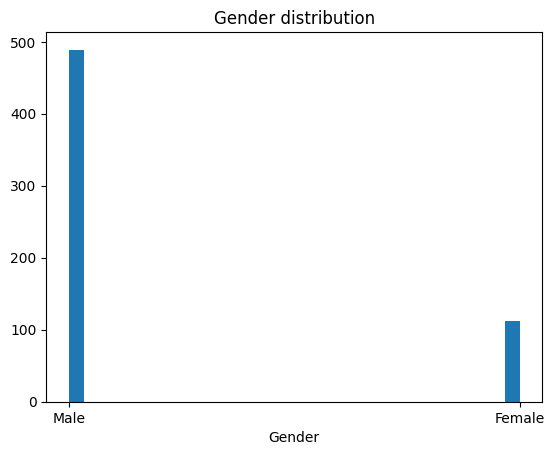

In [55]:
plt.hist(df['Gender'].dropna(),bins=30)
plt.title('Gender distribution')
plt.xlabel('Gender')
plt.show()

In [56]:
df['Gender']=df['Gender'].fillna(df['Gender'].mode()[0])

In [57]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

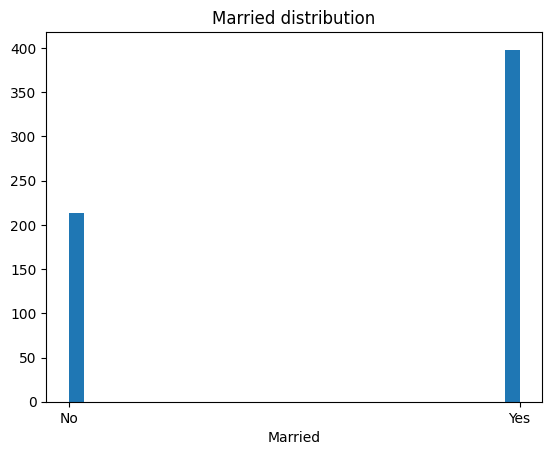

In [58]:
plt.hist(df['Married'].dropna(),bins=30)
plt.title('Married distribution')
plt.xlabel('Married')
plt.show()

In [59]:
df['Married']=df['Married'].fillna(df['Married'].mode()[0])

In [60]:
df['Married'].unique()

array(['No', 'Yes'], dtype=object)

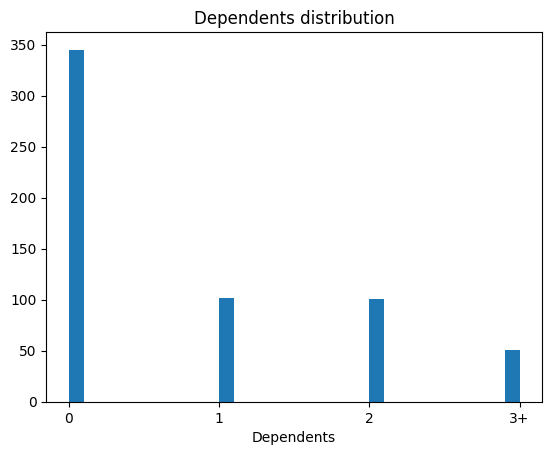

In [61]:
plt.hist(df['Dependents'].dropna(),bins=30)
plt.title('Dependents distribution')
plt.xlabel('Dependents')
plt.show()

In [62]:
df['Dependents']=df['Dependents'].fillna(df['Dependents'].mode()[0])

In [63]:
df['Dependents'].unique()

array(['0', '1', '2', '3+'], dtype=object)

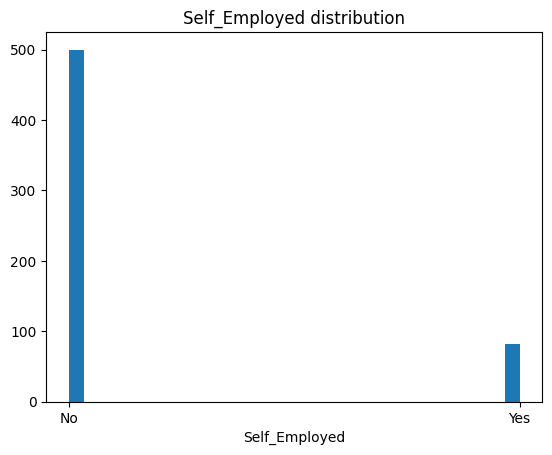

In [64]:
plt.hist(df['Self_Employed'].dropna(),bins=30)
plt.title('Self_Employed distribution')
plt.xlabel('Self_Employed')
plt.show()

In [65]:
df['Self_Employed']=df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

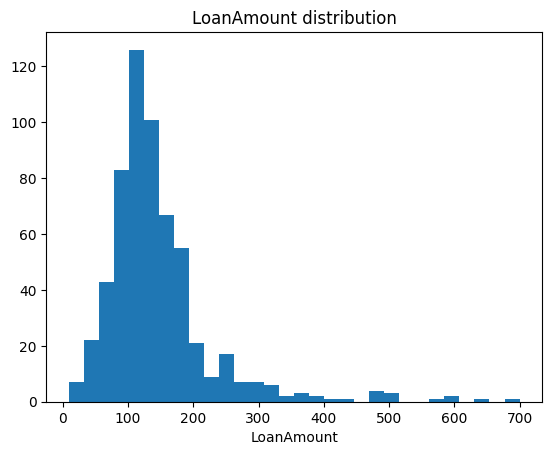

In [66]:
plt.hist(df['LoanAmount'].dropna(),bins=30)
plt.title('LoanAmount distribution')
plt.xlabel('LoanAmount')
plt.show()

In [67]:
df['LoanAmount']=df['LoanAmount'].fillna(df['LoanAmount'].median())

In [68]:
df['LoanAmount'].isnull().sum()

np.int64(0)

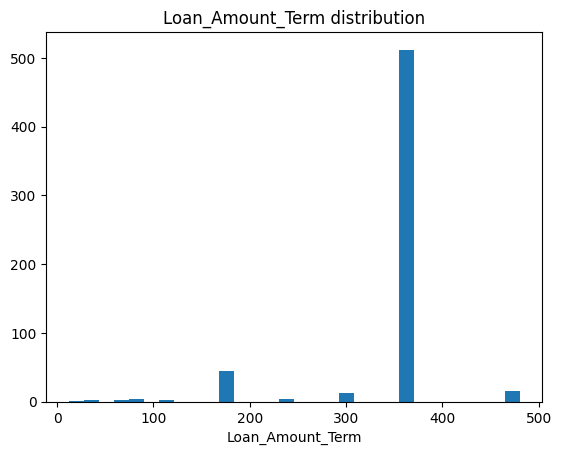

In [69]:
plt.hist(df['Loan_Amount_Term'].dropna(),bins=30)
plt.title('Loan_Amount_Term distribution')
plt.xlabel('Loan_Amount_Term')
plt.show()

In [70]:
df['Loan_Amount_Term']=df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())

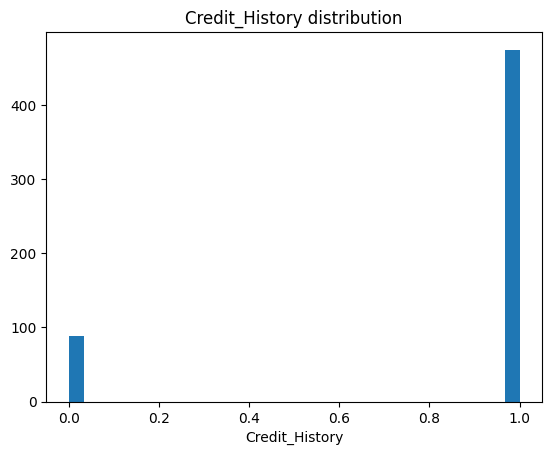

In [71]:
plt.hist(df['Credit_History'].dropna(),bins=30)
plt.title('Credit_History distribution')
plt.xlabel('Credit_History')
plt.show()

In [72]:
df['Credit_History']=df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    object 
 2   Married            614 non-null    object 
 3   Dependents         614 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      614 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [74]:
for col in df.columns:
  print(col,"---> ",df[col].nunique())

Loan_ID --->  614
Gender --->  2
Married --->  2
Dependents --->  4
Education --->  2
Self_Employed --->  2
ApplicantIncome --->  505
CoapplicantIncome --->  287
LoanAmount --->  203
Loan_Amount_Term --->  10
Credit_History --->  2
Property_Area --->  3
Loan_Status --->  2


In [75]:
le=LabelEncoder()
df['Gender']=le.fit_transform(df['Gender'])
df['Married']=le.fit_transform(df['Married'])
df['Dependents']=le.fit_transform(df['Dependents'])
df['Education']=le.fit_transform(df['Education'])
df['Self_Employed']=le.fit_transform(df['Self_Employed'])
df['Property_Area']=le.fit_transform(df['Property_Area'])



In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    int64  
 2   Married            614 non-null    int64  
 3   Dependents         614 non-null    int64  
 4   Education          614 non-null    int64  
 5   Self_Employed      614 non-null    int64  
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    int64  
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(7), object(2)
memory usage: 62.5+ KB


In [77]:
df.drop('Loan_ID', axis=1, inplace=True)

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    int64  
 1   Married            614 non-null    int64  
 2   Dependents         614 non-null    int64  
 3   Education          614 non-null    int64  
 4   Self_Employed      614 non-null    int64  
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    int64  
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(7), object(1)
memory usage: 57.7+ KB


. Exploratory Data Analysis (EDA)

In [ ]:
df.describe()

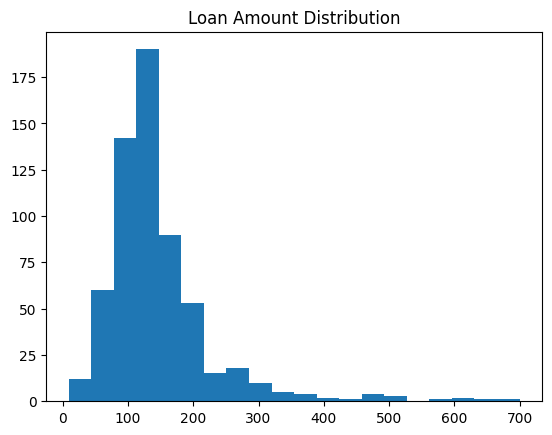

In [80]:
# Distribution of LoanAmount
plt.hist(df['LoanAmount'], bins=20)
plt.title('Loan Amount Distribution')
plt.show()

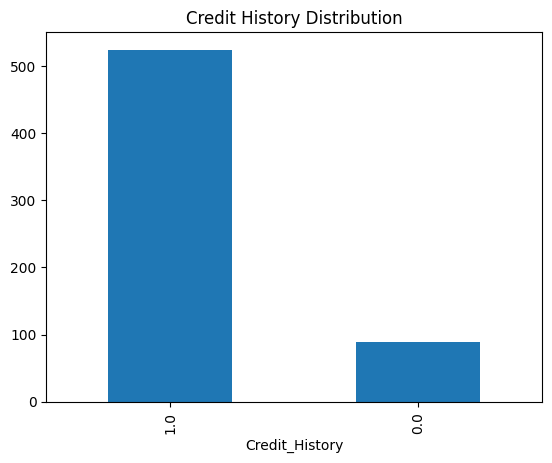

In [81]:
# Bar plot for Credit_History
df['Credit_History'].value_counts().plot(kind='bar')
plt.title('Credit History Distribution')
plt.show()

In [ ]:
# Approval rate vs. features (e.g., boxplot for income vs status)
df.boxplot(column='ApplicantIncome', by='Loan_Status')
plt.title('Applicant Income vs Loan Status')
plt.show()

In [ ]:




#Correlation and Feature Importance
print(df.corr()['Loan_Status'].sort_values(ascending=False))



# Split train and test

In [ ]:
y=df['Loan_Status']
x=df.drop('Loan_Status',axis=1)

In [ ]:
# Assuming x and y are defined earlier in your code
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=42)

k-NN

In [ ]:
# Initializing the model
knn = KNeighborsClassifier(n_neighbors=3)

# Training the model
knn.fit(x_train, y_train)

# Make prediction using the trained model
y_pred = knn.predict(x_test)  # Change from x_train to x_test for evaluation
# Evaluation
acc_knn = accuracy_score(y_test, y_pred)
print("Accuracy:", acc_knn)

rec_knn = recall_score(y_test, y_pred, average='weighted')
print("Recall:", rec_knn)

prec_knn = precision_score(y_test, y_pred, average='weighted')
print("Precision:", prec_knn)

#SVM

In [ ]:
# Initializing the model
svm_classifier = SVC()


# Training the model
svm_classifier.fit(x_train, y_train)

# Make prediction using the trained model
y_pred_svm = svm_classifier.predict(x_test)  # Change from x_train to x_test for evaluation
# Evaluation
acc_svm = accuracy_score(y_test, y_pred_svm)
print("Accuracy:", acc_svm)

rec_svm = recall_score(y_test, y_pred_svm, average='weighted')
print("Recall:", rec_svm)

prec_svm = precision_score(y_test, y_pred_svm, average='weighted')
print("Precision:", prec_svm)

#Decision Tree

In [ ]:
# Initializing the model
dTree = DecisionTreeClassifier(criterion='gini')


# Training the model
dTree.fit(x_train, y_train)

# Make prediction using the trained model
y_pred_dTree = dTree.predict(x_test)  # Change from x_train to x_test for evaluation
# Evaluation
acc_dTree = accuracy_score(y_test, y_pred_dTree)
print("Accuracy:", acc_dTree)

rec_dTree = recall_score(y_test, y_pred_dTree, average='weighted')
print("Recall:", rec_dTree)

prec_dTree= precision_score(y_test, y_pred_dTree, average='weighted')
print("Precision:", prec_dTree)

#Random Forest Classifier

In [ ]:
# Initializing the model
rF_model = RandomForestClassifier(n_estimators=10)


# Training the model
rF_model.fit(x_train, y_train)

# Make prediction using the trained model
y_pred_rf = rF_model.predict(x_test)  # Change from x_train to x_test for evaluation
# Evaluation
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy:", acc_rf)

rec_rf = recall_score(y_test, y_pred_rf, average='weighted')
print("Recall:", rec_rf)

prec_rf = precision_score(y_test, y_pred_rf, average='weighted')
print("Precision:", prec_rf)